# Entrega #02 — Análise Comparativa de Modelos

## Bootcamp de Ciência de Dados — Avanti

**Aluno:** Eraldo Cassimiro  
**Conjunto de dados:** Sleep Efficiency  
**Fonte:** [Kaggle — Sleep Efficiency Dataset](https://www.kaggle.com/datasets/equilibriumm/sleep-efficiency)

## Objetivo

Esta etapa dá continuidade à análise exploratória realizada na Entrega #01. O objetivo é construir e comparar modelos de aprendizado supervisionado capazes de estimar a **eficiência do sono** a partir das características demográficas, dos hábitos de vida e das informações relacionadas ao sono.

Como `Sleep efficiency` é uma variável quantitativa contínua, variando de 0,50 a 0,99 na base, o problema foi definido como uma tarefa de **regressão**. Para facilitar a interpretação dos erros, a variável-alvo será representada em porcentagem, de 50% a 99%.

## Bibliotecas utilizadas

In [1]:
import io
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import KFold, cross_validate, cross_val_predict
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda valor: f"{valor:.3f}")

## Carregamento do conjunto de dados

In [2]:
# No Google Colab, a célula abre a seleção do arquivo CSV.
# Fora do Colab, é possível informar o caminho pela variável de ambiente
# SLEEP_EFFICIENCY_CSV ou manter o CSV na mesma pasta do notebook.
try:
    from google.colab import files

    uploaded = files.upload()
    nome_arquivo = next(iter(uploaded))
    df = pd.read_csv(io.BytesIO(uploaded[nome_arquivo]))
except ImportError:
    caminho_csv = os.environ.get(
        "SLEEP_EFFICIENCY_CSV",
        "Sleep_Efficiency.csv"
    )
    df = pd.read_csv(caminho_csv)

print(f"Quantidade de registros: {df.shape[0]}")
print(f"Quantidade de variáveis: {df.shape[1]}")
df.head()

Quantidade de registros: 452
Quantidade de variáveis: 15


,ID,Age,Gender,Bedtime,Wakeup time,Sleep duration,Sleep efficiency,REM sleep percentage,Deep sleep percentage,Light sleep percentage,Awakenings,Caffeine consumption,Alcohol consumption,Smoking status,Exercise frequency
0,1,65,Female,2021-03-06 01:00:00,2021-03-06 07:00:00,6.000,0.880,18,70,12,0.000,0.000,0.000,Yes,3.000
1,2,69,Male,2021-12-05 02:00:00,2021-12-05 09:00:00,7.000,0.660,19,28,53,3.000,0.000,3.000,Yes,3.000
2,3,40,Female,2021-05-25 21:30:00,2021-05-25 05:30:00,8.000,0.890,20,70,10,1.000,0.000,0.000,No,3.000
3,4,40,Female,2021-11-03 02:30:00,2021-11-03 08:30:00,6.000,0.510,23,25,52,3.000,50.000,5.000,Yes,1.000
4,5,57,Male,2021-03-13 01:00:00,2021-03-13 09:00:00,8.000,0.760,27,55,18,3.000,0.000,3.000,No,3.000


## Metodologia

A análise foi organizada nas seguintes etapas:

1. definição de `Sleep efficiency` como variável-alvo de regressão;
2. remoção de variáveis sem utilidade preditiva e tratamento das variáveis temporais;
3. tratamento de valores ausentes, codificação das variáveis qualitativas e normalização das quantitativas;
4. avaliação dos modelos por validação cruzada *k-fold*;
5. comparação por MAE, RMSE e R²;
6. análise das previsões do modelo com melhor desempenho.

O pré-processamento foi incorporado aos `Pipelines` dos modelos. Assim, em cada divisão da validação cruzada, as estatísticas usadas para imputação e normalização são aprendidas somente com os dados de treinamento. Essa organização evita **vazamento de dados** para a parte usada na validação.

### Verificação da qualidade dos dados

In [3]:
qualidade = pd.DataFrame({
    "Tipo": df.dtypes.astype(str),
    "Ausentes": df.isna().sum(),
    "Percentual ausente (%)": df.isna().mean().mul(100)
})

qualidade[qualidade["Ausentes"] > 0]

,Tipo,Ausentes,Percentual ausente (%)
Awakenings,float64,20,4.425
Caffeine consumption,float64,25,5.531
Alcohol consumption,float64,14,3.097
Exercise frequency,float64,6,1.327


A base contém valores ausentes em `Awakenings`, `Caffeine consumption`, `Alcohol consumption` e `Exercise frequency`. Como os percentuais de ausência são baixos e a base possui apenas 452 registros, os participantes não serão excluídos. Os valores faltantes quantitativos serão preenchidos pela **mediana**, uma medida menos sensível a valores extremos.

Não foram removidos valores discrepantes, pois a EDA mostrou que valores como 5 ou 10 horas de sono e consumo de cafeína igual a 200 são plausíveis e não há evidências de erro de registro.

### Engenharia e seleção de atributos

In [4]:
dados_modelagem = df.copy()

# Transformação cíclica dos horários.
# Em um relógio, por exemplo, 23h30 está próximo de 0h, e a transformação
# em seno e cosseno preserva essa proximidade.
for coluna, prefixo in [
    ("Bedtime", "Bedtime"),
    ("Wakeup time", "Wakeup")
]:
    horario = pd.to_datetime(dados_modelagem[coluna])
    minutos = horario.dt.hour * 60 + horario.dt.minute
    angulo = 2 * np.pi * minutos / (24 * 60)

    dados_modelagem[f"{prefixo} sin"] = np.sin(angulo)
    dados_modelagem[f"{prefixo} cos"] = np.cos(angulo)

# As três fases do sono somam exatamente 100% em todos os registros.
soma_fases = dados_modelagem[[
    "REM sleep percentage",
    "Deep sleep percentage",
    "Light sleep percentage"
]].sum(axis=1)

print(
    "Registros em que as fases do sono somam 100%:",
    int(np.isclose(soma_fases, 100).sum()),
    "de",
    len(dados_modelagem)
)

# ID apenas identifica registros. REM é redundante, pois pode ser obtido
# por 100 - Deep - Light. Os textos originais de horário são substituídos
# pelos quatro componentes cíclicos criados acima.
colunas_removidas = [
    "ID",
    "Bedtime",
    "Wakeup time",
    "REM sleep percentage"
]

dados_modelagem = dados_modelagem.drop(columns=colunas_removidas)

X = dados_modelagem.drop(columns="Sleep efficiency")
y = dados_modelagem["Sleep efficiency"] * 100

print(f"Dimensão de X: {X.shape}")
print(f"Dimensão de y: {y.shape}")
print(f"Intervalo do alvo: {y.min():.0f}% a {y.max():.0f}%")

Registros em que as fases do sono somam 100%: 452 de 452
Dimensão de X: (452, 14)
Dimensão de y: (452,)
Intervalo do alvo: 50% a 99%


A variável `ID` foi removida porque funciona apenas como identificador. As datas de `Bedtime` e `Wakeup time` também não possuem significado preditivo; somente o horário do dia foi preservado por quatro componentes cíclicos.

Como as porcentagens de sono REM, profundo e leve somam exatamente 100%, uma delas é matematicamente redundante. Foi removida `REM sleep percentage`, mantendo as porcentagens de sono profundo e leve, que apresentaram as associações mais fortes com a eficiência durante a EDA. Isso reduz redundância e evita multicolinearidade perfeita na Regressão Linear.

### Pipeline de pré-processamento

In [5]:
variaveis_qualitativas = [
    "Gender",
    "Smoking status"
]

variaveis_quantitativas = [
    coluna for coluna in X.columns
    if coluna not in variaveis_qualitativas
]

pipeline_quantitativo = Pipeline(steps=[
    ("imputacao", SimpleImputer(strategy="median")),
    ("normalizacao", StandardScaler())
])

pipeline_qualitativo = Pipeline(steps=[
    ("imputacao", SimpleImputer(strategy="most_frequent")),
    ("codificacao", OneHotEncoder(handle_unknown="ignore"))
])

preprocessamento = ColumnTransformer(transformers=[
    (
        "quantitativas",
        pipeline_quantitativo,
        variaveis_quantitativas
    ),
    (
        "qualitativas",
        pipeline_qualitativo,
        variaveis_qualitativas
    )
])

print("Variáveis quantitativas:")
print(variaveis_quantitativas)
print("\nVariáveis qualitativas:")
print(variaveis_qualitativas)

Variáveis quantitativas:
['Age', 'Sleep duration', 'Deep sleep percentage', 'Light sleep percentage', 'Awakenings', 'Caffeine consumption', 'Alcohol consumption', 'Exercise frequency', 'Bedtime sin', 'Bedtime cos', 'Wakeup sin', 'Wakeup cos']

Variáveis qualitativas:
['Gender', 'Smoking status']


O pré-processamento atende aos três tratamentos obrigatórios:

- **dados faltantes:** mediana para variáveis quantitativas e categoria mais frequente para qualitativas;
- **codificação:** *one-hot encoding* para `Gender` e `Smoking status`, sem impor uma ordem inexistente entre as categorias;
- **normalização:** `StandardScaler` para colocar as variáveis quantitativas em uma escala comparável, especialmente importante para kNN e SVR.

## Configuração do Experimento

### Validação cruzada

Foi adotada a validação cruzada **k-fold com 5 divisões**, embaralhamento dos registros e `random_state=42`. Com 452 observações, essa estratégia permite que todos os registros sejam usados tanto no treinamento quanto na validação em momentos diferentes, produzindo uma estimativa mais estável que uma única separação *holdout*.

Em cada rodada, aproximadamente 80% da base é usada no treinamento e 20% na validação. Ao final, serão apresentadas a média e o desvio padrão das cinco rodadas.

In [6]:
validacao = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

### Modelos comparados

Foram selecionados cinco modelos de famílias diferentes:

- **DummyRegressor:** baseline que sempre prevê a média observada no conjunto de treinamento;
- **Regressão Linear:** referência simples e interpretável para relações lineares;
- **kNN:** modelo baseado na proximidade entre observações;
- **SVR:** modelo baseado em vetores de suporte, capaz de representar relações não lineares;
- **Random Forest:** conjunto de árvores de decisão capaz de capturar relações não lineares e interações entre variáveis.

Não foi realizada uma busca extensa de hiperparâmetros nesta etapa. O objetivo é comparar as famílias de modelos sob o mesmo processo de validação e estabelecer uma primeira referência de desempenho.

In [7]:
modelos = {
    "DummyRegressor": DummyRegressor(strategy="mean"),
    "Regressão Linear": LinearRegression(),
    "kNN": KNeighborsRegressor(n_neighbors=5),
    "SVR": SVR(kernel="rbf"),
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )
}

### Métricas de avaliação

Foram utilizadas três métricas adequadas à regressão:

- **MAE — Erro Absoluto Médio:** indica, em média, quantos pontos percentuais as previsões se afastam dos valores reais;
- **RMSE — Raiz do Erro Quadrático Médio:** também é expressa em pontos percentuais, mas penaliza mais fortemente erros grandes;
- **R² — Coeficiente de determinação:** mede quanto da variação da eficiência do sono é explicada pelo modelo. Valores maiores e mais próximos de 1 indicam melhor desempenho.

Para MAE e RMSE, valores menores são melhores. Para R², valores maiores são melhores.

In [8]:
metricas = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "R2": "r2"
}

## Resultados e Discussão

### Avaliação dos modelos

In [9]:
resultados_folds = []

for nome, modelo in modelos.items():
    abordagem = Pipeline(steps=[
        ("preprocessamento", preprocessamento),
        ("modelo", modelo)
    ])

    resultados = cross_validate(
        abordagem,
        X,
        y,
        cv=validacao,
        scoring=metricas,
        return_train_score=True,
        n_jobs=-1
    )

    for fold in range(validacao.get_n_splits()):
        resultados_folds.append({
            "Modelo": nome,
            "Fold": fold + 1,
            "MAE": -resultados["test_MAE"][fold],
            "RMSE": -resultados["test_RMSE"][fold],
            "R²": resultados["test_R2"][fold],
            "R² de treino": resultados["train_R2"][fold]
        })

resultados_folds = pd.DataFrame(resultados_folds)

resumo_resultados = (
    resultados_folds
    .groupby("Modelo", sort=False)
    .agg(
        MAE_medio=("MAE", "mean"),
        MAE_desvio=("MAE", "std"),
        RMSE_medio=("RMSE", "mean"),
        RMSE_desvio=("RMSE", "std"),
        R2_medio=("R²", "mean"),
        R2_desvio=("R²", "std"),
        R2_treino_medio=("R² de treino", "mean")
    )
    .sort_values("RMSE_medio")
    .reset_index()
)

resumo_exibicao = resumo_resultados.rename(columns={
    "MAE_medio": "MAE médio",
    "MAE_desvio": "Desvio MAE",
    "RMSE_medio": "RMSE médio",
    "RMSE_desvio": "Desvio RMSE",
    "R2_medio": "R² médio",
    "R2_desvio": "Desvio R²",
    "R2_treino_medio": "R² médio de treino"
})

resumo_exibicao.round(3)

,Modelo,MAE médio,Desvio MAE,RMSE médio,Desvio RMSE,R² médio,Desvio R²,R² médio de treino
0,Random Forest,3.911,0.345,5.121,0.518,0.851,0.044,0.981
1,kNN,4.717,0.327,5.959,0.435,0.800,0.052,0.867
2,Regressão Linear,5.024,0.590,6.246,0.519,0.779,0.060,0.808
3,SVR,5.781,0.486,7.230,0.570,0.710,0.043,0.747
4,DummyRegressor,11.418,0.607,13.501,0.753,-0.004,0.006,0.000


### Comparação visual das métricas

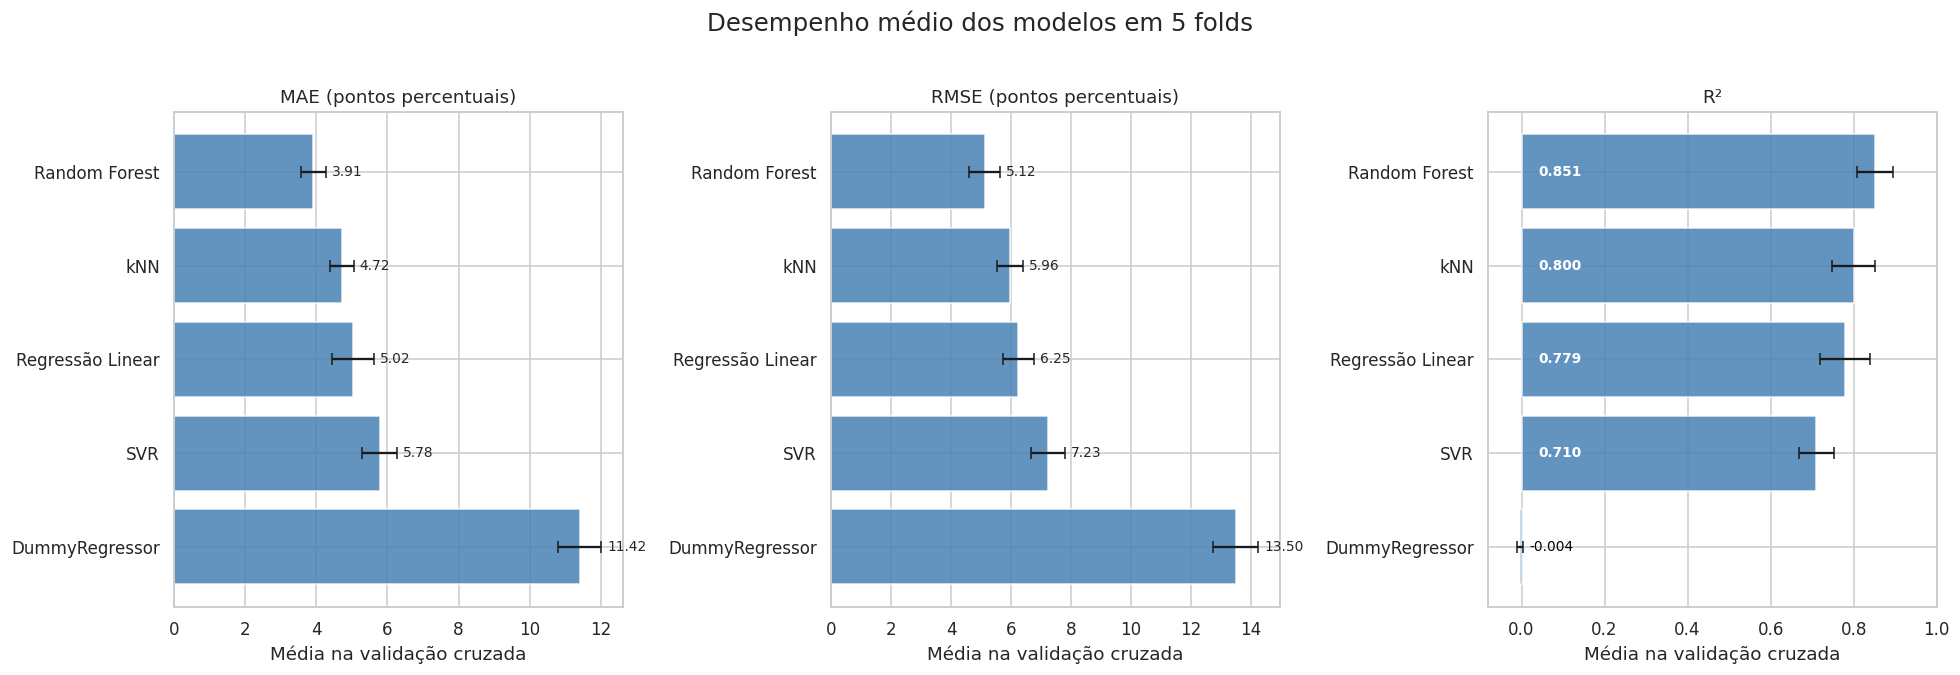

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

configuracoes = [
    ("MAE_medio", "MAE_desvio", "MAE (pontos percentuais)", False),
    ("RMSE_medio", "RMSE_desvio", "RMSE (pontos percentuais)", False),
    ("R2_medio", "R2_desvio", "R²", True)
]

for ax, (media, desvio, titulo, maior_melhor) in zip(
    axes,
    configuracoes
):
    dados_grafico = resumo_resultados.sort_values(
        media,
        ascending=maior_melhor
    )

    barras = ax.barh(
        dados_grafico["Modelo"],
        dados_grafico[media],
        xerr=dados_grafico[desvio],
        color="steelblue",
        alpha=0.85,
        capsize=4
    )

    ax.set_title(titulo)
    ax.set_xlabel("Média na validação cruzada")

    if media == "R2_medio":
        ax.set_xlim(-0.08, 1.0)
        for barra, valor in zip(barras, dados_grafico[media]):
            dentro_da_barra = valor > 0.10
            ax.text(
                0.04 if dentro_da_barra else 0.02,
                barra.get_y() + barra.get_height() / 2,
                f"{valor:.3f}",
                va="center",
                ha="left",
                fontsize=9,
                color="white" if dentro_da_barra else "black",
                fontweight="bold" if dentro_da_barra else "normal"
            )
    else:
        ax.bar_label(barras, fmt="%.2f", padding=4, fontsize=9)

fig.suptitle(
    "Desempenho médio dos modelos em 5 folds",
    fontsize=16,
    y=1.02
)
plt.tight_layout()
plt.show()

### Estabilidade entre as divisões

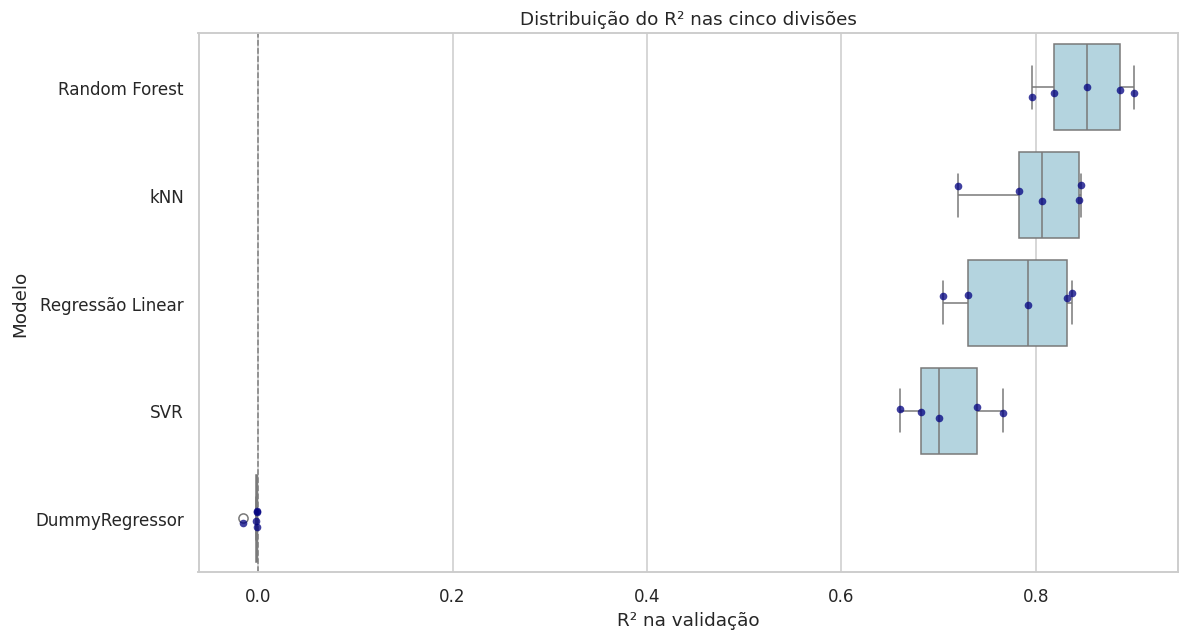

In [11]:
plt.figure(figsize=(11, 6))

ordem_modelos = (
    resumo_resultados
    .sort_values("R2_medio", ascending=False)["Modelo"]
)

sns.boxplot(
    data=resultados_folds,
    x="R²",
    y="Modelo",
    order=ordem_modelos,
    color="lightblue"
)
sns.stripplot(
    data=resultados_folds,
    x="R²",
    y="Modelo",
    order=ordem_modelos,
    color="navy",
    size=5,
    alpha=0.75
)

plt.axvline(0, color="gray", linestyle="--", linewidth=1)
plt.title("Distribuição do R² nas cinco divisões")
plt.xlabel("R² na validação")
plt.ylabel("Modelo")
plt.tight_layout()
plt.show()

### Previsões do melhor modelo

In [12]:
melhor_modelo_nome = resumo_resultados.iloc[0]["Modelo"]
melhor_modelo = modelos[melhor_modelo_nome]

melhor_abordagem = Pipeline(steps=[
    ("preprocessamento", preprocessamento),
    ("modelo", melhor_modelo)
])

previsoes = cross_val_predict(
    melhor_abordagem,
    X,
    y,
    cv=validacao,
    n_jobs=-1
)

mae_oof = mean_absolute_error(y, previsoes)
rmse_oof = np.sqrt(mean_squared_error(y, previsoes))
r2_oof = r2_score(y, previsoes)

print(f"Melhor modelo: {melhor_modelo_nome}")
print(f"MAE fora da amostra: {mae_oof:.2f} pontos percentuais")
print(f"RMSE fora da amostra: {rmse_oof:.2f} pontos percentuais")
print(f"R² fora da amostra: {r2_oof:.3f}")

Melhor modelo: Random Forest
MAE fora da amostra: 3.91 pontos percentuais
RMSE fora da amostra: 5.14 pontos percentuais
R² fora da amostra: 0.855


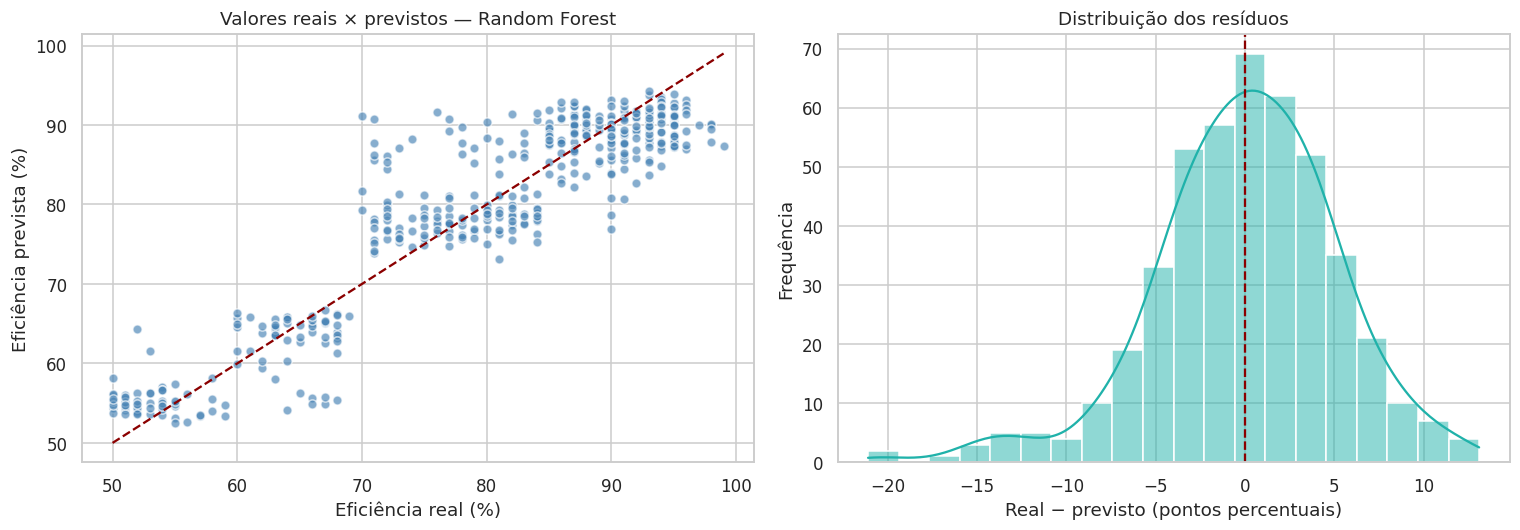

In [13]:
residuos = y - previsoes

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(
    y,
    previsoes,
    alpha=0.65,
    color="steelblue",
    edgecolor="white"
)
limite_min = min(y.min(), previsoes.min())
limite_max = max(y.max(), previsoes.max())
axes[0].plot(
    [limite_min, limite_max],
    [limite_min, limite_max],
    "--",
    color="darkred"
)
axes[0].set_title(f"Valores reais × previstos — {melhor_modelo_nome}")
axes[0].set_xlabel("Eficiência real (%)")
axes[0].set_ylabel("Eficiência prevista (%)")

sns.histplot(
    residuos,
    bins=20,
    kde=True,
    color="lightseagreen",
    ax=axes[1]
)
axes[1].axvline(0, color="darkred", linestyle="--")
axes[1].set_title("Distribuição dos resíduos")
axes[1].set_xlabel("Real − previsto (pontos percentuais)")
axes[1].set_ylabel("Frequência")

plt.tight_layout()
plt.show()

### Interpretação dos resultados

O **Random Forest** apresentou o melhor desempenho geral. Na validação cruzada, obteve **MAE médio de 3,91 pontos percentuais**, **RMSE médio de 5,12 pontos percentuais** e **R² médio de 0,851**. Isso significa que, nas divisões avaliadas, o modelo explicou aproximadamente 85% da variação da eficiência do sono e errou, em média, cerca de 3,9 pontos percentuais.

O **kNN** ficou em segundo lugar, com MAE de 4,72, RMSE de 5,96 e R² de 0,800. A **Regressão Linear** também apresentou um resultado competitivo, com R² de 0,779, sugerindo que parte importante das relações pode ser representada de maneira linear. O **SVR** obteve desempenho inferior aos três modelos anteriores, mas ainda superou claramente o baseline.

O `DummyRegressor`, que prevê somente a média do conjunto de treinamento, apresentou MAE de 11,42, RMSE de 13,50 e R² próximo de zero. Em comparação com esse baseline, o Random Forest reduziu o MAE em aproximadamente **65,7%** e o RMSE em **62,1%**, demonstrando que as variáveis de entrada contêm informação preditiva relevante.

Os desvios padrão foram relativamente baixos, e o Random Forest permaneceu entre os melhores resultados nas cinco divisões. Entretanto, seu R² médio de treinamento foi de aproximadamente 0,981, superior ao R² de validação de 0,851. Essa diferença indica algum grau de **sobreajuste**, embora o desempenho fora da amostra continue forte.

No gráfico de valores reais e previstos, os pontos se concentram ao redor da diagonal, o que indica proximidade entre previsões e valores observados. Ainda assim, existem erros maiores em parte dos registros, visíveis também nas caudas da distribuição dos resíduos.

### Limitações

- A base possui somente 452 registros, o que limita a variedade de padrões disponíveis para treinamento.
- Quatro variáveis possuem dados ausentes. A imputação preserva os registros, mas adiciona valores estimados ao conjunto.
- As fases do sono são matematicamente dependentes; uma delas precisou ser removida para reduzir redundância.
- Os modelos foram comparados sem uma busca extensa de hiperparâmetros. Portanto, os resultados não representam necessariamente o melhor desempenho possível de cada algoritmo.
- O Random Forest apresentou diferença entre o desempenho de treinamento e validação, sugerindo algum sobreajuste.
- O bom desempenho preditivo representa associação entre variáveis e não permite estabelecer relações de causa e efeito.
- A capacidade de generalização para outras populações depende da representatividade da amostra original.

### Próximos passos

Como continuidade, recomenda-se:

1. ajustar os hiperparâmetros dos modelos com validação cruzada aninhada;
2. testar técnicas de regularização e redução do sobreajuste do Random Forest;
3. analisar a importância das variáveis e a explicação individual das previsões;
4. avaliar o desempenho em subgrupos de idade, gênero e tabagismo;
5. validar o modelo em uma base externa e com maior número de participantes.

## Conclusão

A comparação mostrou que todos os modelos treinados com as características dos participantes superaram o baseline. Entre eles, o **Random Forest** apresentou o melhor equilíbrio entre MAE, RMSE e R², seguido pelo kNN e pela Regressão Linear.

Os resultados confirmam que as variáveis identificadas durante a análise exploratória — especialmente características das fases do sono, despertares e hábitos de vida — possuem capacidade preditiva para estimar a eficiência do sono. Ainda assim, o possível sobreajuste e o tamanho limitado da base devem ser considerados antes de qualquer aplicação prática.